##### ARTI 560 - Computer Vision

## Image Classification with Vision Transformer (ViT) - Exercise 

### Objective

In this exercise, you will test the pretrained Vision Transformer (ViT) model on 5 real-world images that you find online.

You will:

1. Download 5 images for different classes in [ImageNet](https://github.com/Waikato/wekaDeeplearning4j/blob/master/docs/user-guide/class-maps/IMAGENET.md).

2. Load the ImageNet class names from a [text file](https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt).

3. Use ViT to predict the class for each image.

4. Record whether the prediction was correct.

#### Important Note

For this exercise, you MUST use the following KerasHub components:

- [keras_hub.models.ViTImageClassifier](https://keras.io/keras_hub/api/models/vit/vit_image_classifier/)

- [keras_hub.models.ViTImageClassifierPreprocessor](https://keras.io/keras_hub/api/models/vit/vit_image_classifier_preprocessor/)

This ensures your input preprocessing (resizing + normalization) matches what the pretrained ViT model expects.

Do not replace the preprocessor with manual normalization (such as dividing by 255), because it may produce incorrect predictions.

ARTI 560 - Computer Vision
Image Classification with Vision Transformer (ViT) - Exercise
Objective
In this exercise, you will test the pretrained Vision Transformer (ViT) model on 5 real-world images that you find online.

You will:

Download 5 images for different classes in ImageNet.

Load the ImageNet class names from a text file.

Use ViT to predict the class for each image.

Record whether the prediction was correct.

Important Note
For this exercise, you MUST use the following KerasHub components:

keras_hub.models.ViTImageClassifier

keras_hub.models.ViTImageClassifierPreprocessor

This ensures your input preprocessing (resizing + normalization) matches what the pretrained ViT model expects.

Do not replace the preprocessor with manual normalization (such as dividing by 255), because it may produce incorrect predictions.

Preprocessor loaded successfully!
ViT model loaded successfully!
Loaded 1000 ImageNet classes
Image 1: Status=200, Size=59705 bytes
 Loaded — True label: golden retriever
Image 2: Status=200, Size=78278 bytes
 Loaded — True label: pizza
Image 3: Status=200, Size=29496 bytes
 Loaded — True label: sports car
Image 4: Status=200, Size=17692 bytes
 Loaded — True label: cat
Image 5: Status=200, Size=67338 bytes
 Loaded — True label: sunflower

Loaded 5 / 5 images


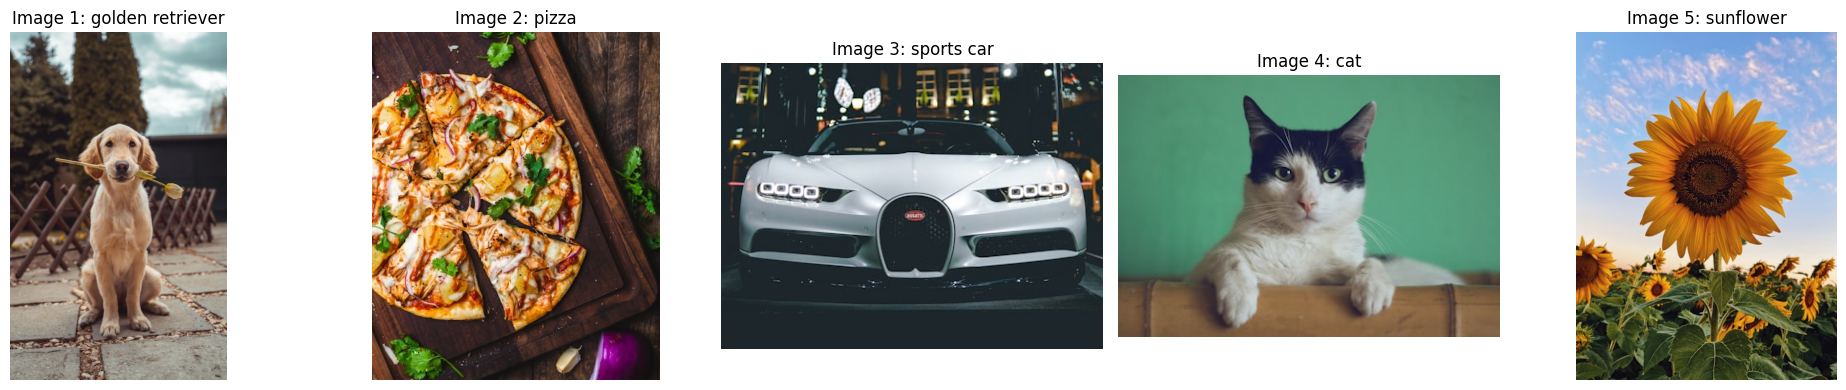


Image File           Predicted Label           True Label           Correct?  
image_1.jpg          golden retriever          golden retriever     Yes       
image_2.jpg          pizza                     pizza                Yes       
image_3.jpg          sports car                sports car           Yes       
image_4.jpg          Egyptian cat              cat                  Yes       
image_5.jpg          monitor                   sunflower            No        


In [5]:
# Import Libraries
import keras
import keras_hub
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import requests
from io import BytesIO

# Load ViTImageClassifierPreprocessor (vit_base_patch16_224_imagenet preset)
preprocessor = keras_hub.models.ViTImageClassifierPreprocessor.from_preset(
    "vit_base_patch16_224_imagenet"
)
print("Preprocessor loaded successfully!")

# Load ViTImageClassifier (vit_base_patch16_224_imagenet preset)
classifier = keras_hub.models.ViTImageClassifier.from_preset(
    "vit_base_patch16_224_imagenet",
    preprocessor=preprocessor,
)
print("ViT model loaded successfully!")

# Load the ImageNet class names from a text file
imagenet_url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
response = requests.get(imagenet_url)
imagenet_classes = response.text.strip().split("\n")
print(f"Loaded {len(imagenet_classes)} ImageNet classes")

image_urls = [
    # 1. Dog
    "https://images.unsplash.com/photo-1552053831-71594a27632d?w=400",
    # 2. Pizza
    "https://images.unsplash.com/photo-1565299624946-b28f40a0ae38?w=400",
    # 3. Sports car
    "https://images.unsplash.com/photo-1544636331-e26879cd4d9b?w=400",
    # 4. Cat
    "https://images.unsplash.com/photo-1514888286974-6c03e2ca1dba?w=400",
    # 5. Sunflower
    "https://images.unsplash.com/photo-1597848212624-a19eb35e2651?w=400",
]

true_labels = [
    "golden retriever",
    "pizza",
    "sports car",
    "cat",
    "sunflower",
]

# Download images 
images = []
for i, img_url in enumerate(image_urls):
    response = requests.get(img_url)
    print(f"Image {i+1}: Status={response.status_code}, Size={len(response.content)} bytes")
    if response.status_code == 200 and len(response.content) > 1000:
        img = Image.open(BytesIO(response.content)).convert("RGB")
        images.append(img)
        print(f" Loaded — True label: {true_labels[i]}")
    else:
        print(f" Failed to load")
        images.append(None)

print(f"\nLoaded {sum(1 for x in images if x is not None)} / {len(image_urls)} images")

# Display the images
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, img in enumerate(images):
    if img:
        axes[i].imshow(img)
    axes[i].set_title(f"Image {i+1}: {true_labels[i]}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

# Predict classes
print(f"\n{'Image File':<20} {'Predicted Label':<25} {'True Label':<20} {'Correct?':<10}")
print("=" * 75)

for i, img in enumerate(images):
    if img is None:
        print(f"{'image_'+str(i+1)+'.jpg':<20} {'FAILED TO LOAD':<25} {true_labels[i]:<20} {'N/A':<10}")
        continue
    img_array = np.array(img)
    img_batch = np.expand_dims(img_array, axis=0)
    predictions = classifier.predict(img_batch, verbose=0)
    predicted_index = np.argmax(predictions, axis=-1)[0]
    predicted_label = imagenet_classes[predicted_index]

    correct = "Yes" if true_labels[i].lower() in predicted_label.lower() or \
                        predicted_label.lower() in true_labels[i].lower() else "No"

    print(f"{'image_'+str(i+1)+'.jpg':<20} {predicted_label:<25} {true_labels[i]:<20} {correct:<10}")

### Record Your Results

Fill the table below based on your results:

| Image File   | Predicted Label | True Label (What you searched) | Correct? (Yes/No) |
| ------------ | --------------- | ------------------------------ | ----------------- |
|image_1.jpg   |golden retriever |      golden retriever          | yes               |
| image_2.jpg  | pizza           |       pizza                    | yes               |
| image_3.jpg  | sports car      |       sports car               | yes               |
| image_4.jpg  | egyption cat    |        cat                     | yes               |
| image_5.jpg  | monitor         |          sunflower             | no                |
